# real_groundtruth_multiregion.ipynb

Multi-region version of `real_groundtruth_downscale.ipynb`.

The four-scene protocol is a case study: tens of thousands of HEALPix cells,
but **four patches and one sensor**. This notebook runs the *same seven steps*
on **real Sentinel-2 patches at the 40 region anchors** already used by the
synthetic multi-region validation, so the real-data claim gets the same
statistical treatment as the synthetic one.

Note these are **Sentinel-2** acquisitions, not the Esri textures the
synthetic multi-region validation uses. They reuse only the *site list*.

**Statistical unit is the region.** One patch per region, ten regions per
scene class. The bootstrap below therefore resamples 10 independent values per
class -- a plain bootstrap over regions, not a cluster bootstrap (with a single
patch per region there is no within-region clustering left to absorb).

**Protocol** (identical to the four-scene notebook, see
`tests/real_groundtruth_common_tools.py`):

1. fetch a real, native 10 m Sentinel-2 B04 patch at the region anchor
2. PSF-aware resample the undegraded data to `NATIVE_LEVEL` (20)
3. plain no-PSF NESTED downgrade to `REF_LEVEL` (19) -- **the reference**
4. Gaussian-blur to the coarse effective resolution (FWHM 25 m)
5. point-sample every `BLOCK`-th pixel (20 m observation)
6. PSF-aware resample the coarse samples onto `REF_LEVEL`
7. compare against the reference, cell-for-cell, at `REF_LEVEL`

## Input data

The 40 patches are a **primary input**, archived like every other one:

```text
notebooks/data/multi_patch_sentinel2/region__<class>__<region_id>_data.zarr
```

They are covered by `notebooks/build_data_manifest.py`, so a normal run reads
them offline. Install the bundle with `load_data_in_zenodo.ipynb` first.

If they are not in the published archive yet, build them once with the
acquisition cell below, then rebuild the manifest and publish a new DOI.

**Prerequisite**: `tables/multi_patch_sites.csv` (written by
`multi_patch_latitude_validation.ipynb`) supplies the site list.

## Setup

In [1]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start=None, marker="healpix_resample"):
    """Walk upward until a directory containing `marker` is found."""
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the repo root above {p}.")


REPO_ROOT = find_repo_root()
MODULE_PATH = REPO_ROOT / "tests" / "real_groundtruth_common_tools.py"
print("module:", MODULE_PATH, "(exists:", MODULE_PATH.exists(), ")")

spec = importlib.util.spec_from_file_location("real_groundtruth_common_tools", MODULE_PATH)
gt = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gt)

gt.describe_config()


module: /home/jovyan/healpix-resample/tests/real_groundtruth_common_tools.py (exists: True )
NATIVE_LEVEL=20: cell size ~= 6.22 m (reference built from real 10 m data, step 2)
REF_LEVEL=19:    cell size ~= 12.44 m (comparison level for every method, vs. 20 m coarse/degraded pixel, step 7)
DEGRADE_PSF_MODE='isotropic': FWHM_x=25.0 m, FWHM_y=25.0 m; isotropic reconstruction FWHM=25.0 m
EDGE_MARGIN_M=200 m excluded from every metric
REFERENCE_MODE='psf_aware', BASELINE_ESTIMAND='cell_average', MAX_ITER=14


## Step 0 -- register the 40 regions

One patch per region, taken at lattice position (1, 1), i.e. the region anchor
itself. The patch is chosen by **position, before any data is fetched or
scored**, so the selection cannot depend on the results.

In [2]:
scenes = gt.load_region_sites()          # patch_row=patch_col=1 by default
print(f"\n{len(scenes)} scenes registered, e.g.:")
for s in scenes[:3]:
    c = gt.region_coordinates[s]
    print(f"  {s:44s} {c['location']:22s} "
          f"lat={c['wgs84']['lat']:7.3f} lon={c['wgs84']['lon']:8.3f}")


Registered 40 regions (4 classes, {'urban': 10, 'water': 10, 'forest': 10, 'agriculture': 10}); 9 candidate patch position(s) each.

40 scenes registered, e.g.:
  region__urban__singapore                     Singapore              lat=  1.290 lon= 103.852
  region__urban__nairobi                       Nairobi, Kenya         lat= -1.286 lon=  36.817
  region__urban__sao_paulo                     Sao Paulo, Brazil      lat=-23.550 lon= -46.633


## Step 1 -- locate the Sentinel-2 patches

Read-only check against the frozen bundle. Nothing is downloaded here.

In [3]:
present = gt.check_region_sites()
available = present.loc[present.present, "scene"].tolist()
display(present[~present.present])
print(f"{len(available)} / {len(present)} region patches usable.")


40/40 region patches present under data/multi_patch_sentinel2.


,scene,path,present


40 / 40 region patches usable.


### One-off: building the bundle (skip if the archive already has it)

`acquire_region_sites()` is the only network call in this notebook and exists
to *construct* an input bundle, not to run an experiment. Run it once, then
rebuild the manifest and publish a new Zenodo version, then set `OFFLINE` back
to `True` so every later run reads archived copies.

A region with no cloud-free acquisition in `gt.REGION_DATE_WINDOW` fails here
and is skipped downstream -- a data-availability criterion, evaluated long
before any method is scored.

#### Preflight: the COG reader

The 40 region patches come from **Element 84's earth-search**, which holds the
complete Sentinel-2 L2A archive as Cloud-Optimized GeoTIFFs, so the same 40
sites as the synthetic validation are all reachable.

The EOPF STAC used for the four paper scenes is a European demonstration
catalogue: queried at these anchors it returned nothing outside Europe and
part of North America -- Amazon, Borneo, Congo, Punjab, Pampas, Tokyo,
Singapore and most of the southern hemisphere all gave `No items` even with a
four-year window at 40% cloud. That is coverage, not weather, so no filter
change could fix it.

Reading COGs needs `rasterio` (declared in the `notebooks` pixi feature):

    pixi run -e notebooks jupyter lab

In [4]:
print("source:", gt.REGION_STAC_SOURCE)
try:
    import rasterio
    print("rasterio", rasterio.__version__, "->", rasterio.__file__)
except ImportError as exc:
    print(f"rasterio is NOT importable ({exc}).\n"
          "Run this notebook with:  pixi run -e notebooks jupyter lab\n"
          "Avoid `!pip install` inside a pixi environment: a PyPI wheel "
          "shadowing conda's libproj is what breaks PROJ and the eopf-zarr "
          "backend (see the warning in pixi.toml).")


source: earth-search
rasterio 1.5.0 -> /srv/conda/envs/notebook/lib/python3.13/site-packages/rasterio/__init__.py


In [5]:
# Leave this cell unexecuted for a normal, offline run.
RUN_ACQUISITION = False

# Provenance first, download second. The bundle was built in two passes -- the
# EOPF demonstration catalogue, then earth-search once EOPF turned out to
# cover only Europe and North America -- so some stores can still carry the
# first pass's endpoint, product and radiometric convention. A blanket
# force=True would re-download all 40 and change every product id, discarding
# 38 perfectly good patches (and the paper's numbers with them). Re-acquiring
# only the heterogeneous stores keeps the change auditable.
prov = gt.region_provenance()
needs_refetch = prov.attrs["needs_refetch"]

if RUN_ACQUISITION:
    gt.OFFLINE = False
    status = gt.acquire_region_sites(scenes=needs_refetch or None,
                                     force=bool(needs_refetch), screen=True)
    gt.OFFLINE = True
    display(status[status.status != "ok"])
    print("\nNow, from the repository root:")
    print("  python notebooks/build_data_manifest.py --doi <new DOI>")
    print("  python notebooks/build_data_manifest.py --check --doi <new DOI>")
    present = gt.check_region_sites()
    available = present.loc[present.present, "scene"].tolist()
    gt.region_provenance()          # confirm the bundle is now homogeneous
else:
    print("Acquisition skipped; using the frozen bundle.")


Provenance: 36/40 stores come from earth-search (https://earth-search.aws.element84.com/v1).
  region__forest__black_forest               https://stac.core.eopf.eodc.eu
  region__forest__finland_boreal             https://stac.core.eopf.eodc.eu
  region__water__lake_constance              https://stac.core.eopf.eodc.eu
  region__water__lake_geneva                 https://stac.core.eopf.eodc.eu

To make provenance homogeneous, re-acquire exactly these:
  gt.acquire_region_sites(scenes=needs_refetch, force=True)
Then rebuild the manifest and re-run the protocol: the product ids change, so the paper's numbers must be re-derived rather than patched.
Acquisition skipped; using the frozen bundle.


## Input-quality screen

The STAC cloud filter is a **scene-level** percentage: a granule reported at
8% cloud can still have our 2.56 km patch entirely under a cloud, and a patch
near a granule edge can be mostly no-data. Both would enter the experiment
looking perfectly legitimate.

Every criterion below reads **only the input patch** -- never a reconstruction
or a score -- and runs before any method, so screening cannot favour any
method. Rejections go to `tables/real_groundtruth_multiregion_quality.csv`.

| Criterion | Threshold | Catches |
|---|---|---|
| shape | full `CENTRAL_SIZE` | patch clipped at a granule edge |
| finite fraction | `MIN_FINITE_FRACTION` = 0.99 | no-data holes |
| relative std | `MIN_RELATIVE_STD` = 1e-3 | flat patch, degenerate reference |
| bright fraction | `MAX_BRIGHT_FRACTION` = 0.30 above 0.30 reflectance | cloud or snow over the patch |

In [6]:
usable, quality = gt.screen_region_patches(available)
display(quality[["scene", "shape", "finite_fraction", "relative_std",
                 "bright_fraction", "usable", "flags"]])


40/40 patches pass the input-quality screen.

Per class among the usable patches:
  agriculture     10
  forest          10
  urban           10
  water           10


,scene,shape,finite_fraction,relative_std,bright_fraction,usable,flags
0,region__agriculture__beauce,256x256,1.000000,0.567459,0.169083,True,
1,region__agriculture__canterbury,256x256,1.000000,0.663296,0.000031,True,
2,region__agriculture__iowa,256x256,1.000000,0.545096,0.000275,True,
3,region__agriculture__mato_grosso,256x256,1.000000,0.164511,0.002304,True,
4,region__agriculture__nile_delta,256x256,1.000000,0.258868,0.117920,True,
5,region__agriculture__pampas,256x256,1.000000,0.662380,0.006439,True,
6,region__agriculture__po_valley,256x256,1.000000,0.329124,0.000076,True,
7,region__agriculture__punjab,256x256,1.000000,0.541817,0.000275,True,
8,region__agriculture__ukraine,256x256,1.000000,0.433206,0.000565,True,
9,region__agriculture__western_australia,256x256,1.000000,0.355075,0.000000,True,


## Steps 2-7 -- run the protocol on every region

Same code path as the four-scene notebook: `run_all()` per scene, then the
per-region rows are concatenated with their scene class and region id.

In [7]:
metrics, failures = gt.run_multiregion(scenes=usable, force=False)

print()
print(metrics.groupby("scene_class").region_id.nunique().rename("regions").to_string())
display(failures)


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


[  1/40] region__agriculture__beauce: 6 rows
[  2/40] region__agriculture__canterbury: 6 rows
[  3/40] region__agriculture__iowa: 6 rows
[  4/40] region__agriculture__mato_grosso: 6 rows
[  5/40] region__agriculture__nile_delta: 6 rows
[  6/40] region__agriculture__pampas: 6 rows
[  7/40] region__agriculture__po_valley: 6 rows
[  8/40] region__agriculture__punjab: 6 rows
[  9/40] region__agriculture__ukraine: 6 rows
[ 10/40] region__agriculture__western_australia: 6 rows
[ 11/40] region__forest__amazon: 6 rows
[ 12/40] region__forest__appalachian: 6 rows
[ 13/40] region__forest__black_forest: 6 rows
[ 14/40] region__forest__borneo: 6 rows
[ 15/40] region__forest__canadian_rockies: 6 rows
[ 16/40] region__forest__congo: 6 rows
[ 17/40] region__forest__finland_boreal: 6 rows
[ 18/40] region__forest__new_zealand: 6 rows
[ 19/40] region__forest__patagonia: 6 rows
[ 20/40] region__forest__tasmania: 6 rows
[ 21/40] region__urban__cape_town: 6 rows
[ 22/40] region__urban__mexico_city: 6 rows


""


### Evaluated-cell screen

The input-quality screen looks at the patch. Nothing yet looked at how many
HEALPix cells the *protocol* actually managed to score. A region whose
reference and reconstruction barely overlap can pass the input screen and
still contribute a handful of cells -- then carry the same weight as a full
region in the region-level mean -- or contribute none at all and silently
shrink every paired comparison.

`n_cells` is identical across all five methods within a region, so this
criterion cannot favour any method.

In [8]:
metrics, dropped_regions = gt.screen_region_metrics(metrics)
if len(dropped_regions):
    display(dropped_regions[["region_id", "scene_class", "method",
                             "n_cells", "rmse"]])


Evaluated-cell screen: median 29,906 cells per region, floor 14,953 (50%).
  40 region(s) retained.


### Geometry integrity check -- every region, not only the dropped ones

`screen_region_metrics` reports *that* a region evaluated too few cells; it
cannot say *why*. Because `n_cells` is identical across all five methods, the
loss happens in the one code path they share, and that path has only four
stages. The cell below measures all four and, crucially, measures them on
**all** regions rather than only the rejected ones.

That is the important part. The failure mode found here -- a derived cache
computed from a patch that was later re-acquired at a different position --
produces a reference for the wrong ground without raising anything. A region
whose patch moved by *less* than the patch width would keep most of its cells,
pass every screen, and quietly contribute a corrupted RMSE to the pooled
comparison. Checking only the regions that already failed would find exactly
the errors large enough to be harmless.

The offsets below must all be a fraction of a pixel. Anything else invalidates
that region's numbers.


In [9]:
# Read-only and cache-backed: no download, no re-solve.
alignment = gt.diagnose_alignment(sorted(set(metrics.scene)), verbose=False)
alignment["offset_m"] = (alignment.offset_x_m**2 + alignment.offset_y_m**2)**0.5
display(alignment.sort_values("offset_m", ascending=False)
        [["scene", "n_ref", "n_interior", "n_finite", "offset_m", "verdict"]]
        .head(10))

bad_geom = alignment[alignment.offset_m > gt.PIXEL_SIZE_M]
if len(bad_geom):
    raise RuntimeError(
        f"{len(bad_geom)} region(s) are georeferenced inconsistently with "
        f"their own raster: {', '.join(bad_geom.scene)}. Their caches predate "
        f"the current patch. Re-run those scenes with force=True (the patch "
        f"fingerprint in the cache name now does this automatically) before "
        f"trusting any number below."
    )
print(f"All {len(alignment)} regions: reference and raster agree to within "
      f"{alignment.offset_m.max():.2f} m (< 1 native pixel).")


,scene,n_ref,n_interior,n_finite,offset_m,verdict
39,region__water__lake_victoria,42771,29925,29925,6.293025,healthy
38,region__water__lake_titicaca,42904,29907,29907,4.539919,healthy
13,region__forest__borneo,42872,29795,29795,3.895831,healthy
27,region__urban__singapore,42929,29955,29955,3.891503,healthy
23,region__urban__nairobi,42915,29906,29906,3.147820,healthy
9,region__agriculture__western_australia,42849,29851,29851,2.479919,healthy
21,region__urban__mexico_city,42900,29816,29816,1.750479,healthy
2,region__agriculture__iowa,42999,29919,29919,1.578314,healthy
15,region__forest__congo,42930,29925,29925,1.370593,healthy
7,region__agriculture__punjab,42880,29915,29915,1.115043,healthy


All 40 regions: reference and raster agree to within 6.29 m (< 1 native pixel).


## How many regions survived, and what that allows

Sentinel-2 availability, not statistics, sets the sample size here. Below
`gt.MIN_REGIONS_FOR_CI` regions a per-class bootstrap interval describes
*which sites happened to be usable*, not the class, so it is suppressed and
the class mean is reported as descriptive only.

In [10]:
availability = gt.region_availability(metrics)
display(availability)


40 regions analysed. Per-class breakdown:
  agriculture     10
  forest          10
  urban           10
  water           10


,scene_class,n_regions,per_class_ci_reportable
0,agriculture,10,True
1,forest,10,True
2,urban,10,True
3,water,10,True


### Primary statistic: pooled paired comparison

Every region counts once; each competitor is paired against PSF-aware *within
the same region*, so between-site scene variability cancels. The sign test is
exact and distribution-free, which is what this sample size calls for.

**This is the number to quote in the paper.**

In [11]:
pooled = gt.paired_summary(metrics)
display(pooled)

for _, r in pooled.iterrows():
    print(f"vs {r.competitor:20s} {int(r.psf_aware_wins):2d}/{int(r.n_regions):2d}"
          f"   sign-test p={r.sign_test_p:.3g}"
          f"   mean delta={r.mean_delta_rmse:+.5f} "
          f"[{r.delta_ci95_low:+.5f}, {r.delta_ci95_high:+.5f}]")


,competitor,n_regions,psf_aware_wins,win_fraction,sign_test_p,mean_delta_rmse,delta_ci95_low,delta_ci95_high
0,classical_cubic,40,40,1.0,1.818989e-12,0.004074,0.002894,0.005321
1,classical_linear,40,40,1.0,1.818989e-12,0.005476,0.003901,0.007160
2,classical_nearest,40,40,1.0,1.818989e-12,0.004983,0.003551,0.006527
3,richardson_lucy,40,40,1.0,1.818989e-12,0.002424,0.001700,0.003242
4,xref,40,40,1.0,1.818989e-12,0.006124,0.004364,0.008001


vs classical_cubic      40/40   sign-test p=1.82e-12   mean delta=+0.00407 [+0.00289, +0.00532]
vs classical_linear     40/40   sign-test p=1.82e-12   mean delta=+0.00548 [+0.00390, +0.00716]
vs classical_nearest    40/40   sign-test p=1.82e-12   mean delta=+0.00498 [+0.00355, +0.00653]
vs richardson_lucy      40/40   sign-test p=1.82e-12   mean delta=+0.00242 [+0.00170, +0.00324]
vs xref                 40/40   sign-test p=1.82e-12   mean delta=+0.00612 [+0.00436, +0.00800]


### The pooled result, as a figure

Left: one point per region, PSF-aware against each competitor, log-log with
the 1:1 line -- every point above the line is a region PSF-aware wins. Right:
mean paired difference with bootstrap interval, annotated with wins/n and the
exact sign test.

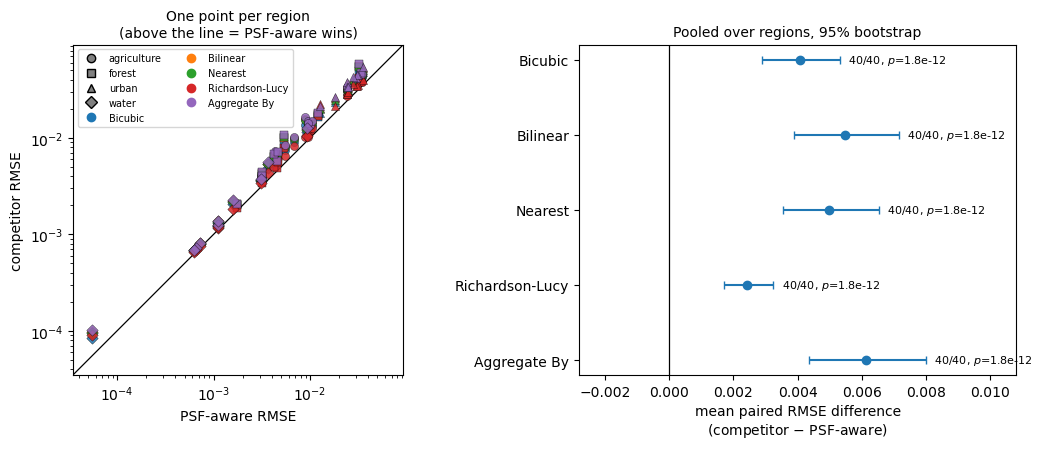

In [12]:
fig = gt.plot_paired_summary(metrics, pooled)


### Ablation: what does the correction buy over the aggregate $\mathbf{B}\mathbf{y}$?

The initial estimate $\mathbf{x}_{\mathrm{ref}}=\mathbf{B}\mathbf{y}$ is the
closest competitor to the full method: identical operator, support, and
readout -- everything except the CG correction. `run_all` now scores it as the
method `xref` (extracted through `resample(..., max_iter=0)`, so the arm is
produced by the estimator's own code path, not a reimplementation).

The bound $J(\hat\delta) \le J(0)$ guarantees the correction cannot worsen
the *observation-space* objective; it says nothing about RMSE to the latent
reference. This cell answers that question in the image domain, on exactly the
same cells and mask as every other method.


In [13]:
# x_ref = By vs full solution, paired per region -- runs off the metrics
# frame produced above, which now contains the 'xref' method rows.
if "xref" not in set(metrics.method):
    raise RuntimeError(
        "No 'xref' rows in the metrics: this run predates the ablation. "
        "Re-run the protocol cell (run_multiregion) with the current tools."
    )

wide = metrics.pivot_table(index=["scene_class", "region_id"],
                           columns="method", values="rmse")
abl = wide[["psf_aware", "xref"]].dropna()
abl["delta"] = abl.xref - abl.psf_aware          # >0: correction helps
abl["rel_gain_pct"] = 100 * abl.delta / abl.xref

per_class = (abl.groupby("scene_class")
             .agg(regions=("delta", "size"),
                  xref_rmse=("xref", "mean"),
                  psf_aware_rmse=("psf_aware", "mean"),
                  mean_delta=("delta", "mean"),
                  mean_rel_gain_pct=("rel_gain_pct", "mean"),
                  wins=("delta", lambda d: int((d > 0).sum()))))
display(per_class.round(5))

from math import comb
n = len(abl); w = int((abl.delta > 0).sum())
p = min(1.0, 2 * sum(comb(n, k) for k in range(w, n + 1)) / 2**n)
print(f"Full solution beats By in {w}/{n} regions "
      f"(exact two-sided sign test p={p:.2e}); "
      f"mean relative gain {abl.rel_gain_pct.mean():.1f}%.")

out = gt.TABLE_DIR / "real_groundtruth_multiregion_xref_ablation.csv"
abl.reset_index().to_csv(out, index=False)
print(f"written: {out.name}")


,regions,xref_rmse,psf_aware_rmse,mean_delta,mean_rel_gain_pct,wins
scene_class,,,,,,
agriculture,10,0.01801,0.01234,0.00566,33.54831,10
forest,10,0.01642,0.01055,0.00586,31.46200,10
urban,10,0.03810,0.02587,0.01223,32.29490,10
water,10,0.00293,0.00218,0.00074,21.60241,10


Full solution beats By in 40/40 regions (exact two-sided sign test p=1.82e-12); mean relative gain 29.7%.
written: real_groundtruth_multiregion_xref_ablation.csv


### Secondary: per-class breakdown (descriptive where n is small)

## Region-level aggregation

Per scene class: mean RMSE per method over regions with a percentile bootstrap
interval, and the paired per-region difference against PSF-aware.

In [14]:
summary, comparisons = gt.summarize_multiregion(metrics)
display(summary)


,scene_class,method,n_regions,mean_rmse,rmse_ci95_low,rmse_ci95_high,ci_reportable,between_region_sd
0,agriculture,classical_cubic,10,0.016063,0.010298,0.023495,True,0.011452
1,agriculture,classical_linear,10,0.017393,0.011335,0.025182,True,0.012000
2,agriculture,classical_nearest,10,0.016960,0.011081,0.024517,True,0.011648
3,agriculture,psf_aware,10,0.012341,0.007617,0.018537,True,0.009455
4,agriculture,richardson_lucy,10,0.014282,0.009183,0.021005,True,0.010193
5,agriculture,xref,10,0.018005,0.011782,0.025988,True,0.012293
6,forest,classical_cubic,10,0.014399,0.005551,0.025649,True,0.017089
7,forest,classical_linear,10,0.015787,0.006006,0.028200,True,0.018896
8,forest,classical_nearest,10,0.015423,0.005887,0.027491,True,0.018412
9,forest,psf_aware,10,0.010551,0.004137,0.018580,True,0.012283


In [15]:
display(comparisons[["scene_class", "competitor", "n_regions",
                     "mean_delta_rmse_competitor_minus_matched",
                     "delta_ci95_low", "delta_ci95_high",
                     "matched_win_fraction"]])

print("win fraction 1.0 everywhere:", bool((comparisons.matched_win_fraction == 1).all()))
print("every paired interval excludes zero:", bool((comparisons.delta_ci95_low > 0).all()))


,scene_class,competitor,n_regions,mean_delta_rmse_competitor_minus_matched,delta_ci95_low,delta_ci95_high,matched_win_fraction
0,agriculture,classical_cubic,10,0.003722,0.002593,0.005040,1.0
1,forest,classical_cubic,10,0.003848,0.001349,0.007240,1.0
2,urban,classical_cubic,10,0.008230,0.006868,0.009652,1.0
3,water,classical_cubic,10,0.000495,0.000145,0.000991,1.0
4,agriculture,classical_linear,10,0.005052,0.003575,0.006752,1.0
5,forest,classical_linear,10,0.005235,0.001831,0.009936,1.0
6,urban,classical_linear,10,0.010960,0.009160,0.012845,1.0
7,water,classical_linear,10,0.000659,0.000183,0.001325,1.0
8,agriculture,classical_nearest,10,0.004619,0.003305,0.006122,1.0
9,forest,classical_nearest,10,0.004872,0.001718,0.009283,1.0


win fraction 1.0 everywhere: True
every paired interval excludes zero: True


## Paper table

In [16]:
table = gt.format_multiregion_table(summary, comparisons)
display(table)


,Scene class,Regions,PSF-aware RMSE,Nearest-neighbor RMSE,Nearest-neighbor delta,Nearest-neighbor delta lo,Nearest-neighbor delta hi,Nearest-neighbor win,Bilinear RMSE,Bilinear delta,...,Richardson-Lucy RMSE,Richardson-Lucy delta,Richardson-Lucy delta lo,Richardson-Lucy delta hi,Richardson-Lucy win,Aggregate By RMSE,Aggregate By delta,Aggregate By delta lo,Aggregate By delta hi,Aggregate By win
0,agriculture,10,0.012341,0.016960,0.004619,0.003305,0.006122,1.0,0.017393,0.005052,...,0.014282,0.001942,0.001396,0.002538,1.0,0.018005,0.005664,0.004012,0.007548,1.0
1,forest,10,0.010551,0.015423,0.004872,0.001718,0.009283,1.0,0.015787,0.005235,...,0.012849,0.002298,0.000819,0.004180,1.0,0.016415,0.005864,0.002051,0.011108,1.0
2,urban,10,0.025873,0.035708,0.009835,0.008223,0.011564,1.0,0.036832,0.010960,...,0.031061,0.005188,0.004093,0.006637,1.0,0.038099,0.012226,0.010234,0.014328,1.0
3,water,10,0.002184,0.002791,0.000607,0.000161,0.001212,1.0,0.002843,0.000659,...,0.002454,0.000270,0.000077,0.000544,1.0,0.002926,0.000742,0.000201,0.001501,1.0


## Figure -- per-class RMSE with bootstrap intervals

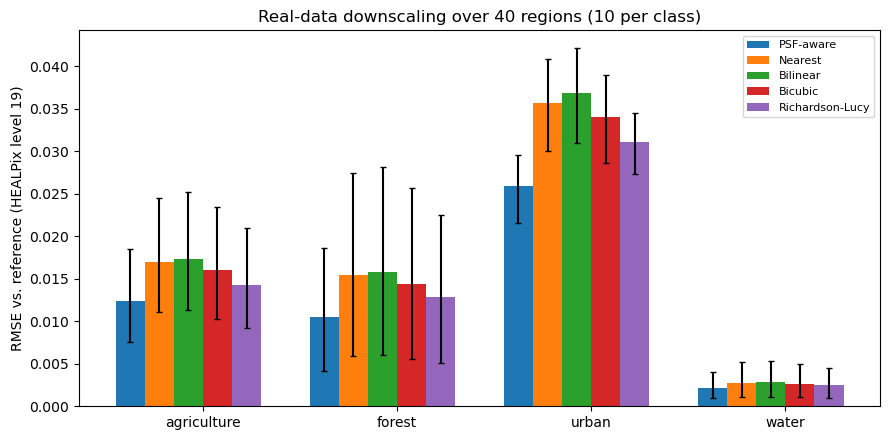

In [17]:
methods = ["psf_aware", "classical_nearest", "classical_linear",
           "classical_cubic", "richardson_lucy"]
labels = {"psf_aware": "PSF-aware", "classical_nearest": "Nearest",
          "classical_linear": "Bilinear", "classical_cubic": "Bicubic",
          "richardson_lucy": "Richardson-Lucy"}
classes = sorted(summary.scene_class.unique())

fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.15
x = np.arange(len(classes))
for i, m in enumerate(methods):
    sub = summary[summary.method == m].set_index("scene_class")
    vals = [sub.loc[c, "mean_rmse"] if c in sub.index else np.nan for c in classes]
    lo = [sub.loc[c, "mean_rmse"] - sub.loc[c, "rmse_ci95_low"] if c in sub.index else 0 for c in classes]
    hi = [sub.loc[c, "rmse_ci95_high"] - sub.loc[c, "mean_rmse"] if c in sub.index else 0 for c in classes]
    ax.bar(x + (i - len(methods) / 2) * width, vals, width,
           yerr=[lo, hi], capsize=2, label=labels[m])
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel(f"RMSE vs. reference (HEALPix level {gt.REF_LEVEL})")
ax.set_title("Real-data downscaling over 40 regions (10 per class)")
ax.legend(fontsize=8)
fig.tight_layout()
gt.FIG_DIR.mkdir(exist_ok=True)
fig.savefig(gt.FIG_DIR / "real_groundtruth_multiregion_rmse.pdf", dpi=200)


## Width-mismatch sweep (real-data analogue of the synthetic mismatch arms)

The degradation stays at 25 m; only the **assumed** reconstruction width
changes. Only PSF-aware and Richardson--Lucy use that width, so the geometric
baselines are untouched by construction (the edge margin is pinned so all arms
score identical cells) -- any drift there would flag a footprint leak, not a
result.

**Why $\pm20\%$ matters and not just $\pm50\%$:** the spectral calibration of
the paper (Section IV-F) cannot distinguish the adopted 12.5 m response from
its $\pm20\%$ alternatives. The realistic uncertainty on an operational
effective response is therefore *of that order*. Testing only $\pm50\%$ leaves
the relevant interval unexamined: if the ranking already flips at $\pm20\%$,
the real-data advantage is fragile in practice; if it holds, the claim gains a
quantified safety margin between what the calibration bounds and where the
method breaks.

In [18]:
# Assumed-width sweep. 1.0 is the matched arm; 0.8/1.2 bracket the
# calibration uncertainty; 0.5/1.5 reproduce the severe arms already reported.
WIDTH_SCALES = [0.5, 0.8, 1.0, 1.2, 1.5]

frames = []
for s in WIDTH_SCALES:
    df = (gt.run_all(force=False) if s == 1.0
          else gt.run_width_mismatch(scale=s))
    frames.append(df[["scene", "method", "rmse"]].assign(scale=s))
sweep = pd.concat(frames, ignore_index=True)

# RMSE of every method at every assumed width, per scene
wide = sweep.pivot_table(index=["scene", "method"], columns="scale", values="rmse")
display(wide.round(4))

# Sanity: the geometric baselines must not move across arms (pinned footprint).
geo = sweep[sweep.method.str.startswith("classical")]
drift = geo.pivot_table(index=["scene", "method"], columns="scale", values="rmse")
max_drift = float((drift.max(axis=1) / drift.min(axis=1) - 1).max())
print(f"geometric-baseline drift across arms: {100 * max_drift:.2e} % "
      f"(anything visible would be a footprint leak, not a result)")

# Where does PSF-aware stop being best?
best = (sweep.loc[sweep.groupby(["scene", "scale"]).rmse.idxmin()]
        [["scene", "scale", "method", "rmse"]]
        .pivot_table(index="scene", columns="scale", values="method",
                     aggfunc="first"))
print("\nbest method per scene and assumed-width scale:")
display(best)

# Margin of PSF-aware over the best competitor (negative = PSF-aware loses)
rows = []
for (scene, s), grp in sweep.groupby(["scene", "scale"]):
    psf = grp.loc[grp.method == "psf_aware", "rmse"].iloc[0]
    other = grp.loc[grp.method != "psf_aware", "rmse"].min()
    rows.append({"scene": scene, "scale": s,
                 "margin_pct": 100 * (other - psf) / other})
margin = (pd.DataFrame(rows)
          .pivot_table(index="scene", columns="scale", values="margin_pct"))
print("\nPSF-aware margin over best competitor (%, negative = loses):")
display(margin.round(1))

out = gt.TABLE_DIR / "real_groundtruth_downscale_width_sweep.csv"
sweep.to_csv(out, index=False)
print(f"\nwritten {out}")


scale                             0.5     0.8     1.0     1.2     1.5
scene       method                                                   
agriculture classical_cubic    0.0112  0.0112  0.0112  0.0112  0.0112
            classical_linear   0.0128  0.0128  0.0128  0.0128  0.0128
            classical_nearest  0.0126  0.0126  0.0126  0.0126  0.0126
            psf_aware          0.0118  0.0089  0.0074  0.0075  0.0116
            richardson_lucy    0.0112  0.0102  0.0085  0.0073  0.0126
            xref               0.0126  0.0126  0.0135  0.0146  0.0162
forest      classical_cubic    0.0127  0.0127  0.0127  0.0127  0.0127
            classical_linear   0.0141  0.0141  0.0141  0.0141  0.0141
            classical_nearest  0.0137  0.0137  0.0137  0.0137  0.0137
            psf_aware          0.0129  0.0104  0.0090  0.0090  0.0129
            richardson_lucy    0.0130  0.0121  0.0106  0.0095  0.0144
            xref               0.0136  0.0139  0.0147  0.0156  0.0169
urban       classical_cubic    0.0353  0.0353  0.0353  0.0353  0.0353
            classical_linear   0.0377  0.0377  0.0377  0.0377  0.0377
            classical_nearest  0.0364  0.0364  0.0364  0.0364  0.0364
            psf_aware          0.0349  0.0303  0.0272  0.0270  0.0347
            richardson_lucy    0.0389  0.0376  0.0354  0.0336  0.0382
            xref               0.0363  0.0373  0.0388  0.0404  0.0424
water       classical_cubic    0.0113  0.0113  0.0113  0.0113  0.0113
            classical_linear   0.0121  0.0121  0.0121  0.0121  0.0121
            classical_nearest  0.0117  0.0117  0.0117  0.0117  0.0117
            psf_aware          0.0113  0.0099  0.0090  0.0089  0.0111
            richardson_lucy    0.0118  0.0112  0.0104  0.0097  0.0115
            xref               0.0117  0.0120  0.0124  0.0129  0.0136

geometric-baseline drift across arms: 2.64e-06 % (anything visible would be a footprint leak, not a result)

best method per scene and assumed-width scale:


scale,0.5,0.8,1.0,1.2,1.5
scene,,,,,
agriculture,richardson_lucy,psf_aware,psf_aware,richardson_lucy,classical_cubic
forest,classical_cubic,psf_aware,psf_aware,psf_aware,classical_cubic
urban,psf_aware,psf_aware,psf_aware,psf_aware,psf_aware
water,psf_aware,psf_aware,psf_aware,psf_aware,psf_aware



PSF-aware margin over best competitor (%, negative = loses):


scale,0.5,0.8,1.0,1.2,1.5
scene,,,,,
agriculture,-5.2,13.0,13.0,-2.4,-3.3
forest,-1.8,13.7,14.7,5.1,-1.6
urban,1.0,14.0,23.0,19.5,1.7
water,0.2,12.2,13.5,7.8,2.2



written tables/real_groundtruth_downscale_width_sweep.csv


## Notes

- Every result-changing setting (`REF_LEVEL`, `BLOCK`, `RECON_FWHM_M`,
  `MAX_ITER`, `REFERENCE_MODE`, `BASELINE_ESTIMAND`, degradation mode) is
  encoded in the cache and CSV filenames via `gt._cache_suffix()`, so variants
  never overwrite each other or the four-scene result the paper's Table VI is
  built from.
- `gt.run_multiregion()` skips a region only when its patch is missing or its
  reference is degenerate. Both criteria are evaluated before any method is
  scored.
- To rerun everything from scratch, pass `force=True`; otherwise cached
  intermediate `.npz` files are reused.

## Control: does the ranking depend on how the reference was built?

The default reference is produced by the same \psf-aware operator family as
one of the methods under test. That is a fair objection: the comparison could
in principle reward the method for sharing machinery with its own target. The
geometric reference removes the objection entirely -- each native 10 m pixel
is assigned to the level-19 cell containing its centre and averaged without
any response model, inversion, or shared code path.

This control existed only for the four illustrative scenes while the main
evidence grew to 40 regions, so it covered a tenth of what it was meant to
control. The cell below runs it on all 40.

**What is comparable and what is not.** The geometric reference targets the
*observed* field, still carrying the sensor's own response, rather than the
latent field. Absolute RMSE values are therefore NOT comparable with the main
run and must never be tabulated beside them. What transfers is the ordering of
the methods, which is precisely what the objection concerns.

Cost: a full recomputation of all 40 regions, since changing the reference
changes the cells every method is read out on. Its caches and CSVs are keyed
separately, so the main run is untouched.


In [19]:
RUN_GEOMETRIC_CONTROL = True     # set False to skip on a quick pass

if RUN_GEOMETRIC_CONTROL:
    geo_metrics, geo_failures = gt.run_multiregion_variant(
        reference_mode="geometric")
    geo_metrics, geo_dropped = gt.screen_region_metrics(geo_metrics)
    ranking = gt.compare_variant_ranking(metrics, geo_metrics)
    display(ranking)
else:
    geo_metrics = ranking = None
    print("Geometric control skipped.")


[  1/40] region__agriculture__beauce: 6 rows
[  2/40] region__agriculture__canterbury: 6 rows
[  3/40] region__agriculture__iowa: 6 rows
[  4/40] region__agriculture__mato_grosso: 6 rows
[  5/40] region__agriculture__nile_delta: 6 rows
[  6/40] region__agriculture__pampas: 6 rows
[  7/40] region__agriculture__po_valley: 6 rows
[  8/40] region__agriculture__punjab: 6 rows
[  9/40] region__agriculture__ukraine: 6 rows
[ 10/40] region__agriculture__western_australia: 6 rows
[ 11/40] region__forest__amazon: 6 rows
[ 12/40] region__forest__appalachian: 6 rows
[ 13/40] region__forest__black_forest: 6 rows
[ 14/40] region__forest__borneo: 6 rows
[ 15/40] region__forest__canadian_rockies: 6 rows
[ 16/40] region__forest__congo: 6 rows
[ 17/40] region__forest__finland_boreal: 6 rows
[ 18/40] region__forest__new_zealand: 6 rows
[ 19/40] region__forest__patagonia: 6 rows
[ 20/40] region__forest__tasmania: 6 rows
[ 21/40] region__urban__cape_town: 6 rows
[ 22/40] region__urban__mexico_city: 6 rows


,run,competitor,n_regions,psf_aware_wins,win_fraction,sign_test_p,mean_delta_rmse,delta_ci95_low,delta_ci95_high
0,main,classical_cubic,40,40,1.0,1.818989e-12,0.004074,0.002894,0.005321
1,main,classical_linear,40,40,1.0,1.818989e-12,0.005476,0.003901,0.007160
2,main,classical_nearest,40,40,1.0,1.818989e-12,0.004983,0.003551,0.006527
3,main,richardson_lucy,40,40,1.0,1.818989e-12,0.002424,0.001700,0.003242
4,main,xref,40,40,1.0,1.818989e-12,0.006124,0.004364,0.008001
5,variant,classical_cubic,40,40,1.0,1.818989e-12,0.002968,0.002100,0.003863
6,variant,classical_linear,40,40,1.0,1.818989e-12,0.004435,0.003157,0.005773
7,variant,classical_nearest,40,40,1.0,1.818989e-12,0.004060,0.002899,0.005285
8,variant,richardson_lucy,40,40,1.0,1.818989e-12,0.001725,0.001147,0.002404
9,variant,xref,40,40,1.0,1.818989e-12,0.005119,0.003646,0.006662


## Align the synthetic validation to the same regions

Sentinel-2 availability decides which regions survive, for reasons unrelated
to the method: catalogue coverage, cloud, granule edges. Comparing a
40-region synthetic result against a smaller real one would leave open whether
a difference comes from the method or from the two experiments sitting on
different sites.

Filtering the synthetic run to the regions that also produced a usable real
patch removes that question. Absolute RMSE still is not comparable between the
two -- the synthetic experiment recovers a known latent texture, the real one
an independently built HEALPix reference -- but the **ranking and the paired
margin over a common set of sites** are.

In [20]:
aligned_synthetic, real_regions = gt.align_synthetic_to_real(metrics)
side_by_side = gt.compare_real_and_synthetic(metrics, aligned_synthetic)
display(side_by_side)


Synthetic aligned to the real sample: 40/40 regions kept.
  per class: {'agriculture': 10, 'forest': 10, 'urban': 10, 'water': 10}


,source,competitor,n_regions,psf_aware_wins,win_fraction,mean_delta_rmse
0,synthetic,classical_cubic,40,40,1.0,0.010697
1,synthetic,classical_linear,40,40,1.0,0.014300
2,synthetic,classical_nearest,40,40,1.0,0.012726
3,real,classical_cubic,40,40,1.0,0.004074
4,real,classical_linear,40,40,1.0,0.005476
5,real,classical_nearest,40,40,1.0,0.004983
6,real,richardson_lucy,40,40,1.0,0.002424
7,real,xref,40,40,1.0,0.006124


## Publish the paper assets

`tex/figures/` and `tex/tables/` are separate copies of what this notebook
writes. Publishing them here keeps the compiled paper in step with the last
run instead of relying on a manual copy.

In [21]:
# Publish notebook outputs into tex/figures and tex/tables.
#
# Loaded by file path rather than by `import`: the module lives in the same
# repository as this notebook, but a checkout that has not been synced yet
# would otherwise fail with a bare ModuleNotFoundError at the very end of a
# long run. Here a missing file says so, and says where it should be.
import importlib.util
from pathlib import Path


def _repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for c in (p, *p.parents):
        if (c / "healpix_resample").is_dir() and (c / "notebooks").is_dir():
            return c
    raise RuntimeError(f"healpix-resample checkout not found above {p}")


_pub = _repo_root() / "notebooks" / "publish_paper_assets.py"
if not _pub.exists():
    print(f"publish_paper_assets.py not found at {_pub}\n"
          f"Nothing was published: tex/figures and tex/tables still hold the\n"
          f"previous run's assets. Sync the repository, then re-run this cell,\n"
          f"or from the repository root:\n"
          f"    python notebooks/publish_paper_assets.py")
else:
    _spec = importlib.util.spec_from_file_location("publish_paper_assets", _pub)
    _mod = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    _mod.publish()


publish_paper_assets: 5 figures cited by main.tex+supplement.tex, 23 declared table CSVs
  added          : 1
      tables/real_groundtruth_multiregion_xref_ablation.csv
  updated        : 4
      figures/real_groundtruth_multiregion_paired.pdf
      tables/real_groundtruth_downscale_metrics.csv
      tables/real_groundtruth_downscale_width_sweep.csv
      tables/real_groundtruth_multiregion_table.csv
  up-to-date     : 22
  missing-source : 1
      figures/fig01_psf_healpix_workflow.pdf

  NOTE: a missing source means the paper cites an asset no notebook has produced yet (or it lives elsewhere). Re-run the notebook that writes it, then call publish() again.

  tex/ was out of date and has been refreshed -- recompile the paper.
